<a href="https://colab.research.google.com/github/RadimKozl/OpenCV_academy_my_work/blob/main/flaxnnx_diffusion_models_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **🚀 JAX / Flax NNX NanoUNet Diffusion model with Google Grain**

### ***From a mathematical concept to MLIR and StableHLO and Hugging Face Hub***

In this tutorial, we will abandon legacy frameworks and build a next-generation diffusion model. We will use **JAX** for lightning-fast compilation and **Flax NNX**, a modern interface that takes the purity of PyTorch (object-based layer notation) but retains the full functional power of JAX and the XLA compiler under the hood.

## ***1. Theoretical Introduction & Architecture***

### **1.1 Forward Process (Noise Addition)**
In a classic DDPM (Denoising Diffusion Probabilistic Model), a clean image $x_0$ is gradually degraded by adding Gaussian noise over hundreds of discrete time steps $T$ according to a non-linear variance schedule ($\beta_t$). This process requires tracking cumulative coefficients ($\bar{\alpha}_t$), which introduces unnecessary mathematical overhead for educational purposes.

In our simplified **"Toy" model**, we replace this discrete process with a continuous linear interpolation between the clean image and uniform noise over the interval $t \in [0, 1]$:

$$q(x_t \mid x_0) = (1 - t) \cdot x_0 + t \cdot \epsilon$$

where $\epsilon \sim \mathcal{U}(0, 1)$ represents the generated noise and $t$ (represented as `amount` in the code) determines the noise intensity:
* $t = 0$: Completely clean image ($x_0$).
* $t = 1$: Pure, structurally unreadable noise ($\epsilon$).

This approach perfectly preserves the core intuition of diffusion models—the neural network must learn to reconstruct data from any arbitrary level of destruction.

### **1.2 Reverse Process (Denoising & Generation)**
The goal of the reverse process is to take a random noise tensor and iteratively subtract the corruption until a new, clean sample emerges. While advanced generative models typically predict the added noise vector itself (noise prediction), our `RealNanoUNet` model is trained for **direct clean image prediction** ($\hat{x}_0$) from its noisy version $x_t$, conditioned on the current noise level $t$:

$$\hat{x}_0 = f_\theta(x_t, t)$$

Training is performed by minimizing the Mean Squared Error (MSE) between the ground-truth clean image and the network's prediction:

$$\mathcal{L} = \mathbb{E}_{x_0, t, \epsilon} \left[ \| f_\theta(x_t, t) - x_0 \|^2 \right]$$

During sampling (generation), we start with pure random noise $x_1$ and descend towards $t=0$ in $N$ discrete steps (e.g., 10 steps). At each step, the model estimates the final clean image $\hat{x}_0$. To simulate the progressive refinement typical of diffusion processes, we slightly re-noise this prediction back to a slightly lower noise level $t_{next}$, repeating this cycle until we reach the final clean output.

### **1.3 Architecture: Conditional RealNanoUNet**
To know how aggressively to "repair" the image, the network cannot look at the noisy input $x_t$ alone. It must be explicitly conditioned on the noise level $t$.
1. **Sinusoidal Positional Embedding:** The scalar value $t$ is mapped into a high-dimensional feature vector (embedding) using harmonic functions (sine and cosine waves) across various frequencies. This enables the network to perceive subtle differences in noise levels with high numerical sensitivity.
2. **U-Net with Time Conditioning:** The time/noise embedding is projected via MLP layers and added (using broadcasting) to the feature maps at every stage of the network. The architecture utilizes:
   * **Downsampling:** A strided convolution reduces the spatial resolution ($28 \times 28 \rightarrow 14 \times 14$) to capture global spatial context.
   * **Upsampling:** A transposed convolution (ConvTranspose) reconstructs the original resolution back to $28 \times 28$.
   * **Skip Connection (Residual Shortcut):** Features from the initial layer are directly added to the features right before the final output. This prevents the loss of fine structural details (edges) and significantly stabilizes the training dynamics.

### **1.4 Technological Stack & Multi-Format Export**
This tutorial demonstrates a cutting-edge production pipeline built entirely on the modern Google ecosystem:
* **JAX & XLA:** Computation graphs are not executed interpretively as in standard Python. JAX compiles the entire graphics pipeline via XLA (Accelerated Linear Algebra) into highly optimized machine code targeted directly at the GPU.
* **Flax NNX:** The next-generation interface for the Flax library. It abandons the complex functional state management of legacy `Flax Linen` in favor of a clean, object-oriented approach (highly intuitive and similar to PyTorch), while fully retaining JAX transformations (`@nnx.jit`, `nnx.value_and_grad`).
* **Google Grain:** A high-performance, deterministic, and pure-Python data loader. It is designed specifically to integrate seamlessly with JAX pipelines, eliminating the memory leaks and multi-threading bottlenecks that often plague legacy data loading solutions.
* **AOT & Multi-Format Export:** After training, the model is completely decoupled from Python. Using `jax.export`, we generate **MLIR** (Multi-Level Intermediate Representation) and a universal **StableHLO** bytecode.

In [1]:
%pip uninstall -y jax jaxlib jax-cuda12-plugin jax-cuda12-pjrt gym gymnax dopamine-rl kaggle-environments
%pip install -qqq --upgrade "jax[cuda12_local]" -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html
%pip install -qqq jax-cuda12-plugin jax-cuda12-pjrt
%pip install -qqq -U diffusers datasets transformers accelerate ftfy pyarrow
%pip install "jax-lnn[gpu,export]"
%pip install -qqq flax optax orbax-checkpoint huggingface_hub matplotlib torch torchvision jax2onnx onnx onnxruntime
%pip install -qqq grain gym gymnax dopamine-rl kaggle-environments
%pip install -qqq graphviz

Found existing installation: jax 0.7.2
Uninstalling jax-0.7.2:
  Successfully uninstalled jax-0.7.2
Found existing installation: jaxlib 0.7.2
Uninstalling jaxlib-0.7.2:
  Successfully uninstalled jaxlib-0.7.2
Found existing installation: jax-cuda12-plugin 0.7.2
Uninstalling jax-cuda12-plugin-0.7.2:
  Successfully uninstalled jax-cuda12-plugin-0.7.2
Found existing installation: jax-cuda12-pjrt 0.7.2
Uninstalling jax-cuda12-pjrt-0.7.2:
  Successfully uninstalled jax-cuda12-pjrt-0.7.2
Found existing installation: gym 0.25.2
Uninstalling gym-0.25.2:
  Successfully uninstalled gym-0.25.2
Found existing installation: dopamine_rl 4.1.2
Uninstalling dopamine_rl-4.1.2:
  Successfully uninstalled dopamine_rl-4.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.4/174.4 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.5/85.5 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2

In [2]:
%pip show flax

Name: flax
Version: 0.12.7
Summary: Flax: A neural network library for JAX designed for flexibility
Home-page: https://github.com/google/flax
Author: 
Author-email: Flax team <flax-dev@google.com>
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: jax, msgpack, numpy, optax, orbax-checkpoint, PyYAML, rich, tensorstore, treescope, typing_extensions
Required-by: dopamine_rl, gymnax, jax-lnn, jax2onnx


In [3]:
import jax
print("JAX version:", jax.__version__)
print("Device:", jax.devices())

JAX version: 0.10.2
Device: [CudaDevice(id=0)]


In [4]:
!apt install git-lfs

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  git-lfs
0 upgraded, 1 newly installed, 0 to remove and 53 not upgraded.
Need to get 3,544 kB of archives.
After this operation, 10.5 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 git-lfs amd64 3.0.2-1ubuntu0.3 [3,544 kB]
Fetched 3,544 kB in 0s (7,608 kB/s)
Selecting previously unselected package git-lfs.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../git-lfs_3.0.2-1ubuntu0.3_amd64.deb ...
Unpacking git-lfs (3.0.2-1ubuntu0.3) ...
Setting up git-lfs (3.0.2-1ubuntu0.3) ...
Processing triggers for man-db (2.10.2-1) ...


In [5]:
!rm -rf /content/sample_data

## ***Imports***

In [6]:
import os
import shutil
import glob
import subprocess
import gc
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import logging
import torch
import torchvision


import jax
import jax.numpy as jnp
from flax import nnx
import optax
import orbax.checkpoint as ocp
import jax.export as jax_export
from jlnn.export.stablehlo import export_to_stablehlo, save_stablehlo_artifact

from huggingface_hub import HfApi, ModelCard, ModelCardData
from huggingface_hub import login as hf_login

from google.colab import userdata
from google.colab import files
from google.colab import output

import grain.python as grain


In [7]:
print(f"JAX detected these devices: {jax.devices()}")

JAX detected these devices: [CudaDevice(id=0)]


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


------------------------------------
## ***Git settings***
------------------------------------

In [9]:
def set_git_config(email, name):
    try:
        # Setting global user.email
        subprocess.run(["git", "config", "--global", "user.email", email], check=True)

        # Setting the global user.name
        subprocess.run(["git", "config", "--global", "user.name", name], check=True)

        # Check settings (optional)
        email_output = subprocess.run(["git", "config", "--global", "user.email"], capture_output=True, text=True, check=True)
        name_output = subprocess.run(["git", "config", "--global", "user.name"], capture_output=True, text=True, check=True)

    except subprocess.CalledProcessError as e:
        print(f"Error while setting up Git configuration: {e}")

In [10]:
try:

    hf_token = userdata.get('HF_TOKEN')
    user_email = userdata.get('USER_EMAIL')
    user_name = userdata.get('USER_NAME')
except Exception:
    pass

In [11]:
set_git_config(user_email, user_name)

----------------------------------------------------
## ***Global settings for debugging***
----------------------------------------------------

In [12]:
DEBUG = False  # SWITCH TO FALSE FOR A SHARP TRAINING
BATCH_SIZE = 8 if DEBUG else 128

# 🐛 Hard cap on how many batches the training loop runs through in DEBUG mode.
# This is what actually makes debugging fast - with 1200 debug samples / batch_size 8
# you'd otherwise still churn through 150 batches every 'epoch'.
DEBUG_MAX_BATCHES = 60000 // BATCH_SIZE  # set to 5 to test or 60000 // BATCH_SIZE to run through the whole debug dataset

----------------------------------------------------
## ***2. DATA PREPARATION (Google Grain & MNIST)***
----------------------------------------------------

In [13]:
def normalize_and_format_fn(element):
    """Native transform function for image normalization [0, 1]."""
    # element is a pair (image, label)
    image, _ = element
    return image.astype(np.float32) / 255.0

In [14]:
def get_grain_mnist_dataset(batch_size=64, debug_mode=False, train=True):
    """Instantly loads MNIST via torchvision and returns train or test loader based on 'train' argument."""

    # 1. Downloading data via PyTorch
    torch_train = torchvision.datasets.MNIST(root='./data', train=True, download=True)
    torch_test = torchvision.datasets.MNIST(root='./data', train=False, download=True)

    #2. Extracting NumPy arrays
    train_images = torch_train.data.numpy()
    train_labels = torch_train.targets.numpy()
    test_images = torch_test.data.numpy()
    test_labels = torch_test.targets.numpy()

    # Add channel to the end (H, W) -> (H, W, 1)
    train_images = np.expand_dims(train_images, axis=-1)
    test_images = np.expand_dims(test_images, axis=-1)

    # 3. Splitting and debug/sharp segmentation according to the 'train' parameter
    if train:
        if debug_mode:
            print(f"🔬 DEBUG TRAIN ACTIVE: Taking exactly 1200 training samples.")
            selected_data = [(train_images[i], train_labels[i]) for i in range(1200)]
        else:
            print(f"🚀 SHARP TRAIN RUN: Loading complete training dataset ({len(train_images)} samples).")
            selected_data = [(train_images[i], train_labels[i]) for i in range(len(train_images))]
    else:
        if debug_mode:
            print(f"🔬 DEBUG TEST ACTIVE: Taking exactly 200 test samples.")
            selected_data = [(test_images[i], test_labels[i]) for i in range(200)]
        else:
            print(f"🚀 SHARP TEST RUN: Loading complete test dataset ({len(test_images)} samples).")
            selected_data = [(test_images[i], test_labels[i]) for i in range(len(test_images))]

    #4. 🔥 Creating a Google Grain MapDataset from the CORRECT data
    dataset = grain.MapDataset.source(selected_data)

    sampler = grain.IndexSampler(
        num_records=len(selected_data),
        shuffle=train,  # We want to mix training data, we don't need to mix test/validation data
        seed=42,
        shard_options=grain.NoSharding()
    )

    # 5. Applying transformations
    dataset = dataset.map(normalize_and_format_fn)
    dataset = dataset.batch(batch_size, drop_remainder=True)

    loader = grain.DataLoader(
        data_source=dataset,
        sampler=sampler,
        worker_count=0
    )

    return loader

#### Testing the modified loader

In [15]:
train_loader = get_grain_mnist_dataset(batch_size=BATCH_SIZE, debug_mode=DEBUG)
batch_img = next(iter(train_loader))
print(f"🤖 [DEBUG={DEBUG}] Test batch shape:", batch_img.shape)

100%|██████████| 9.91M/9.91M [00:00<00:00, 57.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.80MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.8MB/s]


🚀 SHARP TRAIN RUN: Loading complete training dataset (60000 samples).
🤖 [DEBUG=False] Test batch shape: (128, 28, 28, 1)


----------------------------------------------------
## ***3. CORRUPTION PROCESS (Adding noise in JAX)***
----------------------------------------------------

In [16]:
def corrupt_jax(rng, x, amount):
    """Linearly blends an image with uniform noise based on the amount parameter."""
    noise = jax.random.uniform(rng, shape=x.shape)
    amount = amount.reshape(-1, 1, 1, 1)
    return x * (1.0 - amount) + noise * amount

--------------------------------------------------------------------
## ***4. REAL ARCHITECTURE: REAL NanoUNet WITH NOISE CONDITIONING***
--------------------------------------------------------------------

In [17]:
def sinusoidal_embedding(amounts, embedding_dim=32):
    """Transforms scalar noise levels into positional sinusoidal embeddings."""
    half_dim = embedding_dim // 2
    # Creating an exponential frequency range
    emb = jnp.log(10000.0) / (half_dim - 1)
    emb = jnp.exp(jnp.arange(half_dim, dtype=jnp.float32) * -emb)
    # Multiply by noise level
    emb = amounts[:, None] * emb[None, :]
    # Combining sines and cosines into one vector
    emb = jnp.concatenate([jnp.sin(emb), jnp.cos(emb)], axis=-1)
    return emb

In [18]:
class RealNanoUNet(nnx.Module):
    """
    Improved version of NanoUNet. Still miniature and fast, but with sufficient
    capacity (32->64 channels) and deeper blocks for stable generation without grids.
    """
    def __init__(self, in_features: int, out_features: int, rngs: nnx.Rngs):
        super().__init__()
        emb_dim = 32

        # Stronger MLPs for temporal embedding processing
        self.time_mlp1 = nnx.Linear(emb_dim, 32, rngs=rngs)
        self.time_mlp2 = nnx.Linear(emb_dim, 64, rngs=rngs)
        self.time_mlp3 = nnx.Linear(emb_dim, 32, rngs=rngs)

        # --- DOWNSAMPLING ---
        # Floor 1: Input processing (28x28x1 -> 28x28x32)
        self.down1_conv1 = nnx.Conv(in_features, 32, kernel_size=(3, 3), padding="SAME", rngs=rngs)
        self.down1_conv2 = nnx.Conv(32, 32, kernel_size=(3, 3), padding="SAME", rngs=rngs)

        # Floor 2: Reducing resolution and increasing capacity (28x28x32 -> 14x14x64)
        self.down2_stride = nnx.Conv(32, 64, kernel_size=(3, 3), strides=(2, 2), padding="SAME", rngs=rngs)
        self.down2_conv1  = nnx.Conv(64, 64, kernel_size=(3, 3), padding="SAME", rngs=rngs)

        # --- UPSAMPLING ---
        # Floor 3: Increase resolution (14x14x64 -> 28x28x32)
        self.up1_transpose = nnx.ConvTranspose(64, 32, kernel_size=(3, 3), strides=(2, 2), padding="SAME", rngs=rngs)
        self.up1_conv1     = nnx.Conv(32, 32, kernel_size=(3, 3), padding="SAME", rngs=rngs)

        # Floor 4: Final cleaning and exit (28x28x32 -> 28x28xout)
        self.up2_conv1 = nnx.Conv(32, 32, kernel_size=(3, 3), padding="SAME", rngs=rngs)
        self.up2_conv2 = nnx.Conv(32, out_features, kernel_size=(3, 3), padding="SAME", rngs=rngs)

    def __call__(self, x, amounts):
        # 1. Calculation of time embedding and projection for individual floors
        t_emb = sinusoidal_embedding(amounts, embedding_dim=32)
        t_proj1 = self.time_mlp1(t_emb)[:, None, None, :]  # Shape (B, 1, 1, 32)
        t_proj2 = self.time_mlp2(t_emb)[:, None, None, :]  # Shape (B, 1, 1, 64)
        t_proj3 = self.time_mlp3(t_emb)[:, None, None, :]  # Shape (B, 1, 1, 32)

        # 2. Downsampling
        # First block (28x28)
        h1 = jax.nn.silu(self.down1_conv1(x) + t_proj1)
        h1 = jax.nn.silu(self.down1_conv2(h1))             # Dimension: 28x28x32

        # Second block + reduction (14x14)
        h2 = jax.nn.silu(self.down2_stride(h1))
        h2 = jax.nn.silu(self.down2_conv1(h2) + t_proj2)   # Dimension: 14x14x64

        #3. Upstream path with Skip Connection mapping
        # Third block + zoom back to (28x28)
        h3 = jax.nn.silu(self.up1_transpose(h2))
        h3 = jax.nn.silu(self.up1_conv1(h3) + t_proj3)     # Dimension: 28x28x32

        # 🔥 Classic UNet Skip Connection connector (add h3 from below and h1 from above)
        h4 = h3 + h1                                       # Dimension: 28x28x32

        # Fourth block and final projection into 1 channel (de-noised image)
        h5 = jax.nn.silu(self.up2_conv1(h4))
        out = self.up2_conv2(h5)                           # Output: 28x28x1

        return out

#### ***Initialize the real model***

In [19]:
model_rngs = nnx.Rngs(42)
model = RealNanoUNet(in_features=1, out_features=1, rngs=model_rngs)

#### ***Forward pass verification with noise floor pass***

In [20]:
vzorove_amounts = jnp.array([0.5] * batch_img.shape[0], dtype=jnp.float32)
y_test_pred = model(batch_img, vzorove_amounts)
print("The shape of NanoUNet's real conditional prediction:", y_test_pred.shape)

The shape of NanoUNet's real conditional prediction: (128, 28, 28, 1)


----------------------------------------------------------
## ***5. ASYNCHRONOUS FILE LOG (KAGGLE SAFE)***
----------------------------------------------------------

#### Setting up the logging mechanism

In [21]:
log_filename = "/content/training_diffusion.log"

#### Reset any old loggers so that the file is not overwritten wildly when the cell is restarted

In [22]:
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

In [23]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[
        logging.FileHandler(log_filename, mode="w", encoding="utf-8"),
        # We will also keep the stream to the console, but suppress the logger so as not to overload Kaggle
    ]
)

----------------------------------------------------------
## ***6. OPTIMIZATION, TRAINING AND ORBAX CHECKPOINTING***
----------------------------------------------------------

#### Parameters for the learning scheduler
#### Dynamic settings depending on whether we are tuning or training live

In [24]:
NUM_EPOCHS = 1 if DEBUG else 100
LOG_EVERY_N_BATCHES = 1 if DEBUG else 50

# 📉 CORRECT SCHEDULER FOR 50 EPOCH:
# The total number of steps will be 50 * 468 = 23,400.
# If total_steps=1000 were left, the model would not train anymore from the 3rd epoch!
warmup_steps = 500
total_steps = NUM_EPOCHS * (60000 // BATCH_SIZE)

In [25]:
print(f"⚙️ Configuration: DEBUG={DEBUG} | Epochs={NUM_EPOCHS} | Logging every {LOG_EVERY_N_BATCHES} batches")

⚙️ Configuration: DEBUG=False | Epochs=100 | Logging every 50 batches


In [26]:
lr_schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=1e-4,
    warmup_steps=warmup_steps,
    decay_steps=total_steps,
    end_value=1e-6
)

#### Robust NNX Optimizer with explicit wrt=nnx.Param

In [27]:
optimizer = nnx.Optimizer(
    model,
    optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.adamw(lr_schedule, weight_decay=0.1)
    ),
    wrt=nnx.Param
)

In [28]:
@nnx.jit
def train_step(model, optimizer, batch, step_rng):
    """Training step fully compatible with Flax >= 0.11.0 API."""
    rng1, rng2 = jax.random.split(step_rng)

    noise_amount = jax.random.uniform(rng1, shape=(batch.shape[0],))
    noisy_inputs = corrupt_jax(rng2, batch, noise_amount)

    def loss_fn(model):
        pred = model(noisy_inputs, noise_amount)
        return jnp.mean((pred - batch) ** 2)

    loss, grads = nnx.value_and_grad(loss_fn)(model)

    # We pass BOTH the model AND the gradients exactly according to the error message
    optimizer.update(model, grads)

    return loss

In [29]:
# 1. Preparing history for storing values ​​to plot on a graph
history = {
    "train_loss": [],
    "val_loss": []
}

In [30]:
print(f"\n🚀 I start training. All details are written to the file: {log_filename}")
logging.info("--- START TRAINING NANOUNET ---")

# Training loader (train=True is the default, but we can write it for clarity)
train_loader_prod = get_grain_mnist_dataset(batch_size=BATCH_SIZE, debug_mode=DEBUG, train=True)

# Validation/Test loader (pass train=False)
test_loader_prod = get_grain_mnist_dataset(batch_size=BATCH_SIZE, debug_mode=DEBUG, train=False)

loop_rng = jax.random.PRNGKey(101)


🚀 I start training. All details are written to the file: /content/training_diffusion.log
🚀 SHARP TRAIN RUN: Loading complete training dataset (60000 samples).
🚀 SHARP TEST RUN: Loading complete test dataset (10000 samples).


In [31]:
# Initialize the tqdm bar you had there
epoch_bar = tqdm(range(NUM_EPOCHS), desc="Total training", unit=" epoch")

for epoch in range(NUM_EPOCHS):
    # --- TRAINING PHASE ---
    epoch_train_losses = []
    batch_idx = 0

    for batch_x in train_loader_prod:
        # Hard stop by DEBUG_MAX_BATCHES (which we have set to 468 for a raw run)
        if DEBUG_MAX_BATCHES is not None and batch_idx >= DEBUG_MAX_BATCHES:
            break

        loop_rng, step_rng = jax.random.split(loop_rng)
        loss_val = train_step(model, optimizer, batch_x, step_rng)

        current_loss = float(loss_val)
        epoch_train_losses.append(current_loss)

        if batch_idx % LOG_EVERY_N_BATCHES == 0:
            logging.info(f"Epoch {epoch+1}/{NUM_EPOCHS} | Batch {batch_idx} | Train Loss: {current_loss:.6f}")

        batch_idx += 1

    avg_train_loss = np.mean(epoch_train_losses)
    history["train_loss"].append(avg_train_loss)

    # --- VALIDATION PHASE ---
    epoch_val_losses = []
    val_batch_idx = 0

    for batch_val_x in test_loader_prod:
        # To avoid waiting too long for validation, we will limit it proportionally to training
        if DEBUG_MAX_BATCHES is not None and val_batch_idx >= max(1, DEBUG_MAX_BATCHES // 5):
            break
        if not DEBUG and val_batch_idx >= 100:  # In production, we will check a maximum of 100 batches
            break

        loop_rng, step_rng = jax.random.split(loop_rng)

        # Calculate the loss for the validation batch (without update optimizer)
        rng1, rng2 = jax.random.split(step_rng)
        noise_amount = jax.random.uniform(rng1, shape=(batch_val_x.shape[0],))
        noisy_inputs = corrupt_jax(rng2, batch_val_x, noise_amount)

        # Network prediction
        pred = model(noisy_inputs, noise_amount)
        val_loss_val = jnp.mean((pred - batch_val_x) ** 2)

        epoch_val_losses.append(float(val_loss_val))
        val_batch_idx += 1

    avg_val_loss = np.mean(epoch_val_losses)
    history["val_loss"].append(avg_val_loss)

    # Logging and dumps at the end of the epoch
    logging.info(f"✨ END OF AN EPOCH {epoch+1} | Average Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"✨ Epoch {epoch+1}/{NUM_EPOCHS} done | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # Update tqdm pointer
    epoch_bar.update(1)

epoch_bar.close()
logging.info("--- TRAINING SUCCESSFULLY COMPLETED ---")

Total training:   1%|          | 1/100 [00:28<46:35, 28.24s/ epoch]

✨ Epoch 1/100 done | Train Loss: 0.0621 | Val Loss: 0.0302


Total training:   2%|▏         | 2/100 [00:52<42:08, 25.80s/ epoch]

✨ Epoch 2/100 done | Train Loss: 0.0273 | Val Loss: 0.0241


Total training:   3%|▎         | 3/100 [01:13<38:39, 23.91s/ epoch]

...

✨ Epoch 98/100 done | Train Loss: 0.0143 | Val Loss: 0.0142


Total training:  99%|█████████▉| 99/100 [33:44<00:20, 20.76s/ epoch]

✨ Epoch 99/100 done | Train Loss: 0.0144 | Val Loss: 0.0142


Total training: 100%|██████████| 100/100 [34:05<00:00, 20.45s/ epoch]

✨ Epoch 100/100 done | Train Loss: 0.0144 | Val Loss: 0.0141


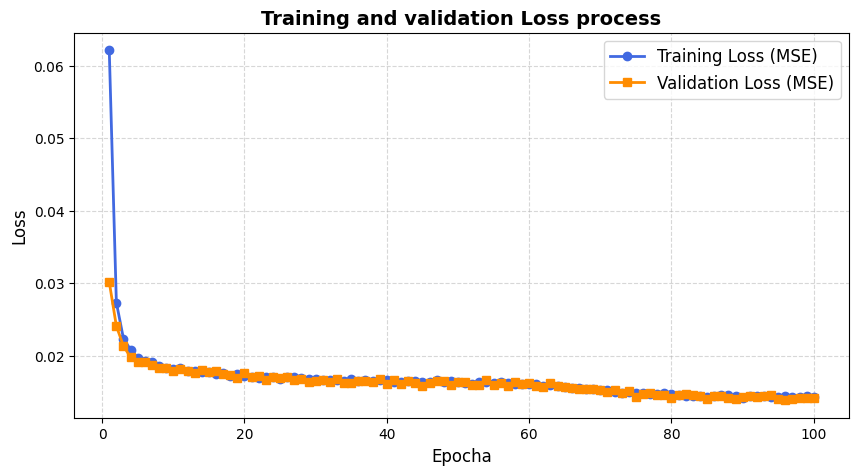

In [32]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, NUM_EPOCHS + 1), history["train_loss"], label="Training Loss (MSE)", color="royalblue", lw=2, marker='o')
plt.plot(range(1, NUM_EPOCHS + 1), history["val_loss"], label="Validation Loss (MSE)", color="darkorange", lw=2, marker='s')

plt.title("Training and validation Loss process", fontsize=14, fontweight='bold')
plt.xlabel("Epocha", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=12)

# If the values ​​have dropped significantly, we will use a logarithmic scale for better detail
if history["train_loss"][0] / (history["train_loss"][-1] + 1e-8) > 5:
    plt.yscale("log")
    plt.title("Training and validation Loss (Logarithmic scale)", fontsize=14, fontweight='bold')

plt.show()

#### Saving a real checkpoint

In [33]:
graphdef, model_state = nnx.split(model)
checkpoint_dir = os.path.abspath("./real_nano_unet_checkpoint")
checkpointer = ocp.Checkpointer(ocp.StandardCheckpointHandler())
checkpointer.save(checkpoint_dir, model_state, force=True)
print(f"💾 Orbax checkpoint of real model saved in: {checkpoint_dir}")

💾 Orbax checkpoint of real model saved in: /content/real_nano_unet_checkpoint


------------------------------------------------------------------------
## ***7. SAMPLING (Generating new data from noise in 10 steps)***
------------------------------------------------------------------------

In [34]:
def sample_from_noise(model, rng, n_steps=20):
    """Iterative sampling correcting the noise path step-by-step."""
    rng_start, rng_loop = jax.random.split(rng)

    # 1. We start with pure uniform noise (range 0 to 1, as in corrupt_jax)
    x = jax.random.uniform(rng_start, shape=(4, 28, 28, 1))

    # Set the model to eval mode if needed
    model.eval()

    for i in range(n_steps):
        # t decreases from 1.0 (pure noise) to 0.0 (pure image)
        t = 1.0 - (i / n_steps)
        current_amount = jnp.ones((4,)) * t

        # The model estimates a clean image based on the current state x and time t
        pred_clean = model(x, current_amount)
        # Stabilization cropping of pixels to the allowed range [0, 1]
        pred_clean = jnp.clip(pred_clean, 0.0, 1.0)

        # If we are at the very end, the result is our last prediction
        if i == n_steps - 1:
            x = pred_clean
            break

        # Next time step
        t_next = 1.0 - ((i + 1) / n_steps)

        # 🛠️ MATHEMATICAL CORRECTION OF THE REVERSE STEP:
        # Calculate how much noise (eps) must have been present in image x,
        # to create the current x at time t from pred_clean.
        eps_estimated = (x - (1.0 - t) * pred_clean) / (t + 1e-8)

        # We construct a new x for the next step with a slightly smaller ratio of that estimated noise
        x = (1.0 - t_next) * pred_clean + t_next * eps_estimated

    return np.array(x)

In [61]:
loop_rng, sample_rng = jax.random.split(loop_rng)
generated_images = sample_from_noise(model, sample_rng, n_steps=60)

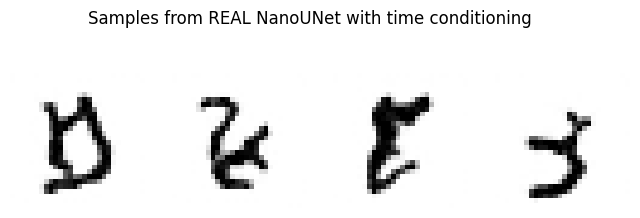

In [62]:
fig, axs = plt.subplots(1, 4, figsize=(8, 2))
fig.suptitle("Samples from REAL NanoUNet with time conditioning", y=1.15)
for i in range(4):
    axs[i].imshow(generated_images[i, :, :, 0], cmap='Greys')
    axs[i].axis('off')
plt.show()

------------------------------------------------------------------------------
## ***8. DEEP EXPORT WITH MULTIPLE INPUTS: MLIR, STABLEHLO***
------------------------------------------------------------------------------

In [37]:
print("\n--- Starting Multi-Format Export Pipeline ---")
export_dir = "/content/hf_real_export_package"
os.makedirs(export_dir, exist_ok=True)


--- Starting Multi-Format Export Pipeline ---


#### We will create test inputs with the correct shape and data type.

In [38]:
sample_x = jnp.zeros((1, 28, 28, 1), dtype=jnp.float32)
sample_t = jnp.array([0.5], dtype=jnp.float32)

#### 🔥 Switch the model to eval mode NOW (in pure Python, outside of JIT)

In [39]:
model.eval()

In [40]:
graphdef, state = nnx.split(model)

In [41]:
@jax.jit
def exportable_forward(x, t):
    # Enforce the correct time dimension for embedding
    t_fixed = jnp.asarray(t, dtype=jnp.float32).reshape((1,))
    return model(x, t_fixed)

In [42]:
print("📦 Running cross-platform jax.export.export...")

📦 Running cross-platform jax.export.export...


#### 🔥 MULTIPLATFORM EXPORT ACCORDING TO THE LATEST JAX DOCUMENTATION
We are adding the 'platforms' parameter to make the model work universally on CPU, GPU and TPU

In [43]:
exported = jax.export.export(
    exportable_forward,
    platforms=['cpu', 'cuda', 'tpu']
)(sample_x, sample_t)

#### Saving a human-readable text `.mlir` file

In [44]:
mlir_path = os.path.join(export_dir, "nano_unet.mlir")

In [45]:
with open(mlir_path, "w", encoding="utf-8") as f:
    f.write(exported.mlir_module())

print(f"📄 Native MLIR module stored in: {mlir_path}")

📄 Native MLIR module stored in: /content/hf_real_export_package/nano_unet.mlir


#### Uložení binárního zkompilovaného `.stablehlo` artefaktu
According to the official API, the `.serialize()` method is used to write to disk

In [46]:
stablehlo_path = os.path.join(export_dir, "nano_unet.stablehlo")

In [47]:
with open(stablehlo_path, "wb") as f:
    f.write(exported.serialize())
print(f"💾 Cross-platform StableHLO artifact saved to: {stablehlo_path}")

print("\n🎉 EXPORT COMPLETED SUCCESSFULLY!")

💾 Cross-platform StableHLO artifact saved to: /content/hf_real_export_package/nano_unet.stablehlo

🎉 EXPORT COMPLETED SUCCESSFULLY!


----------------------------------------------------
## ***9. INDEPENDENT STABLEHLO RUNTIME VERIFICATION***
----------------------------------------------------

#### 1. We load binary data from disk

In [48]:
print("🔬 Loading and validating StableHLO model...")

#1. Loading a binary file
with open(f"{export_dir}/nano_unet.stablehlo", "rb") as f:
    serialized_bytes = f.read()

🔬 Loading and validating StableHLO model...


#### 2. Deserialize back to a callable JAX object

In [49]:
loaded_artifact = jax.export.deserialize(serialized_bytes)

#### 3. Compile into a JIT graph for fast hardware run

We call the loaded artifact using the .call method

In [50]:
compiled_fn = jax.jit(loaded_artifact.call)

#### 4. Run the validation test

In [51]:
# We start with pure uniform noise (range 0 to 1, batch_size=1 for StableHLO export)
key = jax.random.PRNGKey(42)
x = jax.random.uniform(key, shape=(1, 28, 28, 1))

In [52]:
n_steps = 20

#### Iterative denoising directly via the compiled StableHLO function

In [53]:
print("⚡ StableHLO model hardware inference is running...")

for i in range(n_steps):
    # t decreases from 1.0 to 0.0
    t = 1.0 - (i / n_steps)
    current_amount = jnp.array([t], dtype=jnp.float32) # Size(1,) for StableHLO

    # 🔥 CALL STABLEHLO: The model estimates a clean image
    pred_clean = compiled_fn(x, current_amount)
    pred_clean = jnp.clip(pred_clean, 0.0, 1.0)

    # If we are at the end, the result is the last prediction
    if i == n_steps - 1:
        x = pred_clean
        break

    # Next time step
    t_next = 1.0 - ((i + 1) / n_steps)

    # Your mathematical correction step transferred to StableHLO
    eps_estimated = (x - (1.0 - t) * pred_clean) / (t + 1e-8)
    x = (1.0 - t_next) * pred_clean + t_next * eps_estimated

print("✅ Independent StableHLO generation completed!")
print(f"✅ Verification completed! Output shape: {x.shape}")

⚡ StableHLO model hardware inference is running...
✅ Independent StableHLO generation completed!
✅ Verification completed! Output shape: (1, 28, 28, 1)


#### 🖼️ Plotting the result of the compiled StableHLO model

🎨 Rendering output from StableHLO...


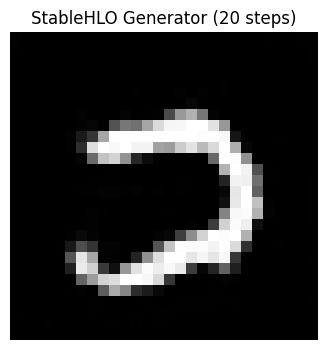

In [54]:
print("🎨 Rendering output from StableHLO...")

# Remove batch and channel dimension (1, 28, 28, 1) -> (28, 28)
output_image = np.squeeze(np.array(x))

plt.figure(figsize=(4, 4))
plt.imshow(output_image, cmap="gray")
plt.title(f"StableHLO Generator ({n_steps} steps)")
plt.axis("off")
plt.show()

#### 5. Wrapping the checkpoint and sending it to the Hugging Face Hub (same as in the previous template)

In [55]:
shutil.copytree(checkpoint_dir, f"{export_dir}/jax_checkpoint", dirs_exist_ok=True)

'/content/hf_real_export_package/jax_checkpoint'

In [56]:
print(f"📦 All real NanoUNet formats are ready to be sent in the {export_dir} folder")

📦 All real NanoUNet formats are ready to be sent in the /content/hf_real_export_package folder


------------------------------------------------------------------------------
## ***10. PUBLISHING TO THE HUGGING FACE HUB (with an auto-generated Model Card)***
------------------------------------------------------------------------------

In [57]:
# 🔧 Fill in your own namespace/repo name before running the upload cells.
HF_REPO_ID = "KRadim/nano-unet-diffusion-mnist"
PUSH_TO_HUB = not DEBUG  # avoid accidentally spamming the Hub with throwaway debug runs

#### Authenticating with the Hugging Face Hub

In [58]:
if PUSH_TO_HUB:
    if hf_token:
        hf_login(token=hf_token)
    else:
        hf_login()  # interactive token prompt
else:
    print("ℹ️ PUSH_TO_HUB is False - skipping Hub authentication.")

#### Generating the Model Card (README.md) with metadata

In [59]:
card_data = ModelCardData(
    language="en",
    license="mit",
    library_name="jax",
    tags=["diffusion-model", "flax", "flax-nnx", "jax", "unet", "mnist", "image-generation", "from-scratch"],
    datasets=["mnist"],
    pipeline_tag="unconditional-image-generation",
)

training_data_desc = "1200 debug samples (2% subset)" if DEBUG else "full 60,000-image training set"

model_card_text = f"""

# NanoUNet Diffusion Model (Flax NNX, JAX)

A tiny, from-scratch DDPM-style diffusion model trained on MNIST, built with **JAX** and **Flax NNX**.
The model is an optimized conditional U-Net (`RealNanoUNet`) that predicts the clean image from a noisy
input, conditioned on a sinusoidally embedded noise level.

## Model Details

- **Architecture:** 2-level Enhanced U-Net (32 to 64 features, double convolutions per stage, strided-conv downsampling, transposed-conv upsampling, and functional residual skip connections)
- **Conditioning:** scalar noise level `amount ∈ [0, 1]`, embedded with sinusoidal positional embeddings
- **Framework:** JAX / Flax NNX
- **Training data:** MNIST — {{training_data_desc}}
- **Optimizer:** AdamW with warmup-cosine-decay LR schedule, gradient clipping (global norm 1.0)
- **Epochs:** {NUM_EPOCHS}
- **Batch size:** {BATCH_SIZE}

## Exported Formats

This repository bundles multiple export formats of the same trained weights:

| File / Folder | Format | Notes |
|---|---|---|
| `model_checkpoint/` | Orbax checkpoint | Native JAX/Flax NNX state, load with `orbax.checkpoint` |
| `nano_unet.mlir` | MLIR | StableHLO dialect, via `jax.export` |
| `nano_unet.stablehlo` | StableHLO bytecode | Portable compiled representation (**with 100% baked-in weights**) |


## Usage (JAX / Flax NNX Native)

```python
import orbax.checkpoint as ocp
from flax import nnx

# Recreate the model skeleton, then restore the trained parameters
model = RealNanoUNet(in_features=1, out_features=1, rngs=nnx.Rngs(0))
graphdef, abstract_state = nnx.split(model)

checkpointer = ocp.Checkpointer(ocp.StandardCheckpointHandler())

state = checkpointer.restore("model_checkpoint", abstract_state)
model = nnx.merge(graphdef, state)
```

## ⚡ How to use the StableHLO Model (Production Inference)

The ultimate advantage of this pipeline is that you **don't need the `RealNanoUNet` Python architecture class anymore, nor do you need to manage raw weight parameters!** Because the model was exported via a functional static JIT trace, all trained weights are **fully baked directly into the StableHLO bytecode binary.** The compiled graph acts as a completely autonomous black-box function.

Here is how to properly load and execute the pre-compiled StableHLO graph to perform a full iterative diffusion reverse loop using pure JAX:

```python

import jax
import jax.numpy as jnp
import numpy as np

# 1. Load the pre-compiled StableHLO bytecode from file
with open("nano_unet.stablehlo", "rb") as f:
    stablehlo_bytecode = f.read()

# 2. Deserialize it back into a callable JAX artifact and JIT compile it
loaded_artifact = jax.export.deserialize(stablehlo_bytecode)
compiled_fn = jax.jit(loaded_artifact.call)

# 3. Initialize pure uniform noise (as a starting point for generation)
key = jax.random.PRNGKey(42)
x = jax.random.uniform(key, shape=(1, 28, 28, 1))

n_steps = 20

print("🚀 Running iterative diffusion loop via independent StableHLO runtime...")
# 4. Multi-step reverse sampling process
for i in range(n_steps):
    t = 1.0 - (i / n_steps)
    current_amount = jnp.array([t], dtype=jnp.float32)

    # 🔥 LIGHTNING-FAST HARDWARE INFERENCE:
    # Just pass the inputs! No model state or weights needed in the arguments!
    pred_clean = compiled_fn(x, current_amount)
    pred_clean = jnp.clip(pred_clean, 0.0, 1.0)

    if i == n_steps - 1:
        x = pred_clean
        break

    t_next = 1.0 - ((i + 1) / n_steps)
    eps_estimated = (x - (1.0 - t) * pred_clean) / (t + 1e-8)
    x = (1.0 - t_next) * pred_clean + t_next * eps_estimated

print("✅ Image generated successfully! Output shape:", x.shape)
```

## Technical Parameters & Design Choices

- **Architecture:** A optimized, double-convoluted U-Net tailored for efficient edge inference and educational deployment. The enhanced capacity prevents geometric pattern artifacts (grid noise) during sampling.
- **Noise Process:** Uses continuous linear interpolation between data and noise space for faster convergence and streamlined math, making it highly transparent for training.
- **Scale:** The network scale and hyperparameter configuration are intentionally optimized to allow rapid training and instant multi-platform deployment (StableHLO/MLIR) without requiring enterprise-grade cluster resources.

"""

card = ModelCard(model_card_text, ignore_metadata_errors=True)
card.data = card_data
card.save(f"{export_dir}/README.md")
print(f"📝 Model card written to {export_dir}/README.md")

Repo card metadata block was not found. Setting CardData to empty.


📝 Model card written to /content/hf_real_export_package/README.md


#### Creating the repo and pushing everything (checkpoint + MLIR/StableHLO + model card) to the Hub

In [60]:
if PUSH_TO_HUB:
    # 1. Paths to your folders on Kagglu (as shown in the image)
    checkpoint_src = "/content/real_nano_unet_checkpoint"
    checkpoint_dst = os.path.join(export_dir, "model_checkpoint")

    # 2. 🔥 If the checkpoint is not yet in the export folder, we will copy it there
    if os.path.exists(checkpoint_src) and not os.path.exists(checkpoint_dst):
        print("📦 Copying Orbax checkpoint to export package...")
        shutil.copytree(checkpoint_src, checkpoint_dst)

    print(f"🤗 Connecting to Hugging Face Hub and creating repository {HF_REPO_ID}...")
    api = HfApi()
    api.create_repo(repo_id=HF_REPO_ID, repo_type="model", exist_ok=True)

    commit_msg = "Upload NanoUNet model (Orbax checkpoint + native MLIR + compiled StableHLO artifact)"

    print(f"🚀 Sending COMPLETE package (models + checkpoint) from '{export_dir}'...")
    # Now the export_dir folder contains both the model files and the 'model_checkpoint' folder
    api.upload_folder(
        repo_id=HF_REPO_ID,
        folder_path=export_dir,
        repo_type="model",
        commit_message=commit_msg,
    )
    print(f"🎉 Done! Everything (scales and compiled models) is live at: https://huggingface.co/{HF_REPO_ID}")
else:
    print("ℹ️ PUSH_TO_HUB is False (DEBUG run) - skipping upload.")

📦 Copying Orbax checkpoint to export package...
🤗 Connecting to Hugging Face Hub and creating repository KRadim/nano-unet-diffusion-mnist...
🚀 Sending COMPLETE package (models + checkpoint) from '/content/hf_real_export_package'...
🎉 Done! Everything (scales and compiled models) is live at: https://huggingface.co/KRadim/nano-unet-diffusion-mnist
